In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv("customer_shopping_data.csv")

# Preview data
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [71]:
# Check missing values
print(df.isnull().sum())

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Convert invoice_date to datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)


invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64
Duplicate rows: 0


In [72]:
# Descriptive statistics for numerical columns
stats = df[['age', 'quantity', 'price']].describe()
print(stats)


                age      quantity         price
count  99457.000000  99457.000000  99457.000000
mean      43.427089      3.003429    689.256321
std       14.990054      1.413025    941.184567
min       18.000000      1.000000      5.230000
25%       30.000000      2.000000     45.450000
50%       43.000000      3.000000    203.300000
75%       56.000000      4.000000   1200.320000
max       69.000000      5.000000   5250.000000


In [73]:
print("Mean:\n", df[['age','quantity','price']].mean())
print("Median:\n", df[['age','quantity','price']].median())
print("Mode:\n", df[['age','quantity','price']].mode().iloc[0])
print("Standard Deviation:\n", df[['age','quantity','price']].std())


Mean:
 age          43.427089
quantity      3.003429
price       689.256321
dtype: float64
Median:
 age          43.0
quantity      3.0
price       203.3
dtype: float64
Mode:
 age          37.00
quantity      3.00
price       600.16
Name: 0, dtype: float64
Standard Deviation:
 age          14.990054
quantity      1.413025
price       941.184567
dtype: float64


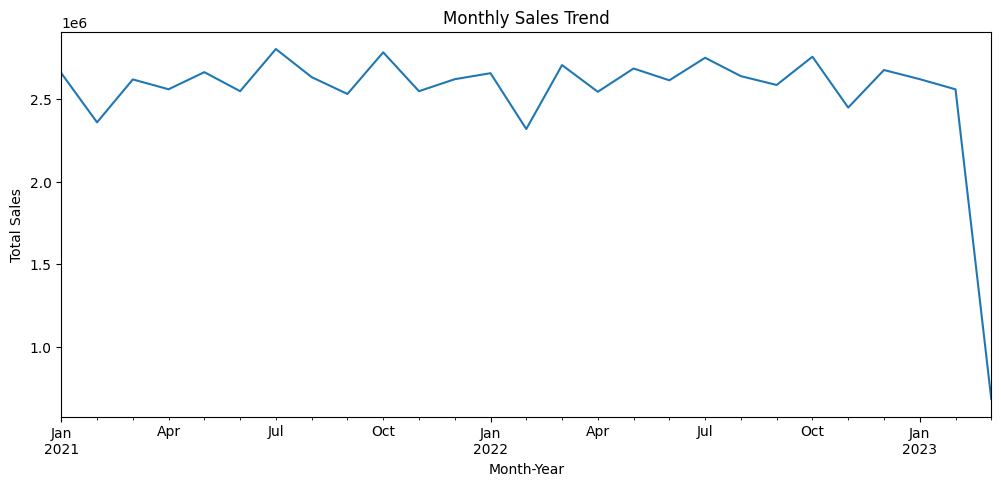

In [74]:
# Create month-year column
df['month_year'] = df['invoice_date'].dt.to_period('M')

# Monthly sales
monthly_sales = df.groupby('month_year')['price'].sum()

# Plot
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Total Sales")
plt.show()


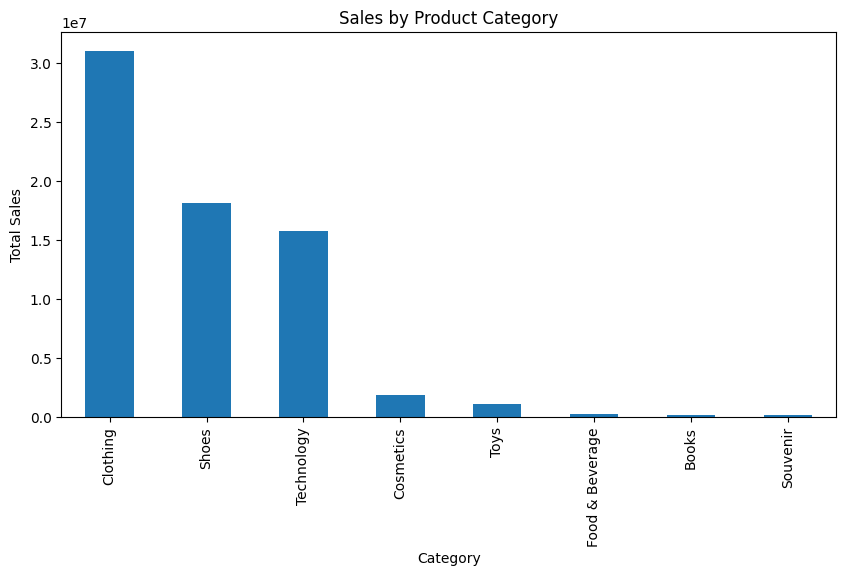

In [75]:
category_sales = df.groupby('category')['price'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
category_sales.plot(kind='bar')
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()


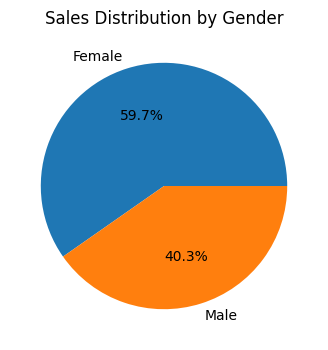

In [76]:
gender_sales = df.groupby('gender')['price'].sum()

plt.figure(figsize=(6,4))
gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Gender")
plt.ylabel("")
plt.show()


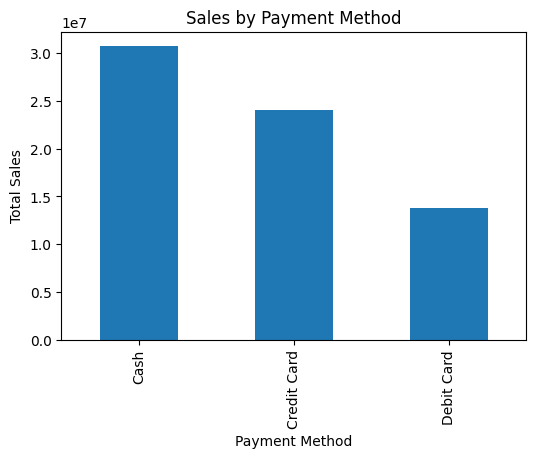

In [77]:
payment_sales = df.groupby('payment_method')['price'].sum()

plt.figure(figsize=(6,4))
payment_sales.plot(kind='bar')
plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.show()


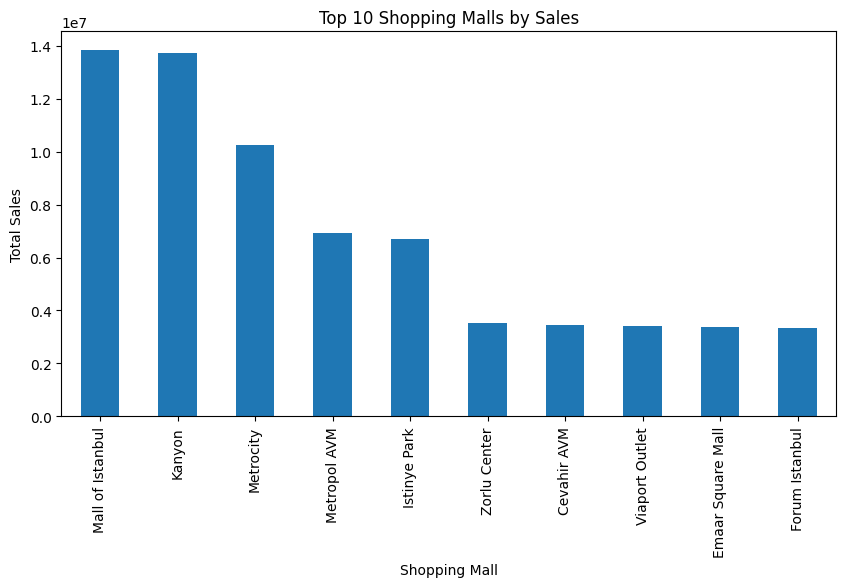

In [78]:
mall_sales = df.groupby('shopping_mall')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
mall_sales.plot(kind='bar')
plt.title("Top 10 Shopping Malls by Sales")
plt.xlabel("Shopping Mall")
plt.ylabel("Total Sales")
plt.show()


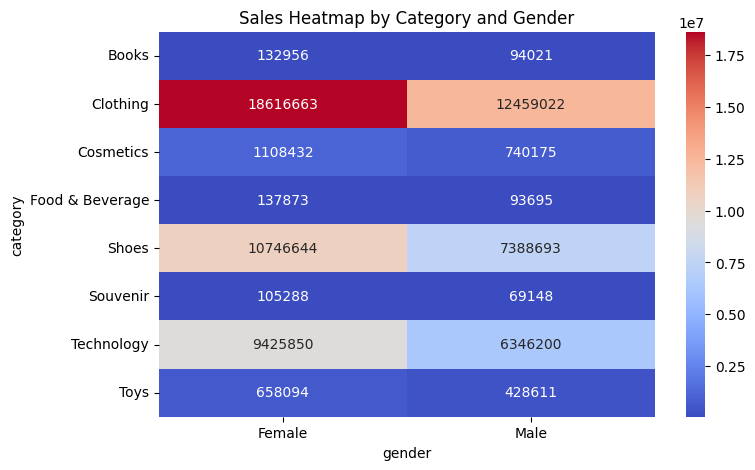

In [79]:
pivot_table = df.pivot_table(values='price', index='category', columns='gender', aggfunc='sum')

plt.figure(figsize=(8,5))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='coolwarm')
plt.title("Sales Heatmap by Category and Gender")
plt.show()


In [80]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
